In [ ]:
# Importando dataframes 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [171]:
#Caminhos
path_dolar = r"C:\Users\lucas.takabayashi\Desktop\GitHub\agro-analysis\data\dolar.xlsx"
path_milho = r"C:\Users\lucas.takabayashi\Desktop\GitHub\agro-analysis\data\milho.xlsx"
path_soja = r"C:\Users\lucas.takabayashi\Desktop\GitHub\agro-analysis\data\soja.xlsx"

In [172]:
#Criação de um DataFrame de data com início de 01/01/2020 a 30/04/2026
df_data = pd.DataFrame({
        'data': pd.date_range(start='2020-01-01', end='2026-04-30', freq='C', )
    })

In [173]:
#Adicionando colunas de Ano, mês e ano mês
df_data['ano'] = df_data['data'].dt.year
df_data['mes'] = df_data['data'].dt.month
df_data['ano_mes'] = df_data['data'].dt.to_period('M')


In [174]:
#Criando função para ler dados e padronizar colunas
def tratamento_dados(caminho, header=1):

    #Lendo arquivo e padronizando colunas e casas decimais
    df = pd.read_excel(caminho, header=header, decimal=',')

    #Padronizando colunas
    df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

    #Convertendo data
    df['data'] = pd.to_datetime(df['data'], format='%d/%m/%Y')

    return df

In [175]:
#Aplicando função em cada dataset
df_dolar = tratamento_dados(path_dolar,header=3)
df_milho = tratamento_dados(path_milho,header=3)
df_soja = tratamento_dados(path_soja,header=3)

In [160]:
print(
    f'df_dolar colunas: {list(df_dolar.columns)} \n'
    f'df_soja  colunas: {list(df_soja.columns)} \n'
    f'df_milho colunas: {list(df_milho.columns)} \n'
)

df_dolar colunas: ['data', 'à_vista_r$'] 
df_soja  colunas: ['data', 'à_vista_r$', 'à_vista_us$'] 
df_milho colunas: ['data', 'à_vista_r$', 'à_vista_us$'] 



In [176]:
#Renomeando as colunas principais
df_dolar.rename(columns={'à_vista_r$': 'dolar'}, inplace=True)
df_soja.rename(columns={'à_vista_r$': 'soja_scs'}, inplace=True)
df_milho.rename(columns={'à_vista_r$': 'milho_scs'}, inplace=True)

In [162]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1652 entries, 0 to 1651
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     1652 non-null   datetime64[ns]
 1   ano      1652 non-null   int32         
 2   mes      1652 non-null   int32         
 3   ano_mes  1652 non-null   period[M]     
dtypes: datetime64[ns](1), int32(2), period[M](1)
memory usage: 38.8 KB


In [177]:
#Juntos os dataframes em um único só
df_main = (df_data.merge(df_dolar, how='left', on='data')
    .merge(df_soja, how='left', on='data')
    .merge(df_milho, how='left', on='data'))

In [164]:
df_main.columns

Index(['data', 'ano', 'mes', 'ano_mes', 'dolar', 'soja_scs', 'à_vista_us$_x',
       'milho_scs', 'à_vista_us$_y'],
      dtype='object')

In [178]:
#Dropando colunas de dólar
df_main.drop(columns=['à_vista_us$_x','à_vista_us$_y'], inplace=True)

In [180]:
#Preenchendo valores vazios com o último valor
df_main.ffill(inplace=True)

In [181]:
#Dropando os valores vazios
df_main.dropna(inplace=True)

In [182]:
#Criando colunas de variação de preço por dia
cols = ['soja_scs','milho_scs','dolar']
for i in cols:
    df_main[f'{i}_var'] = (df_main[i].pct_change() * 100).round(2)

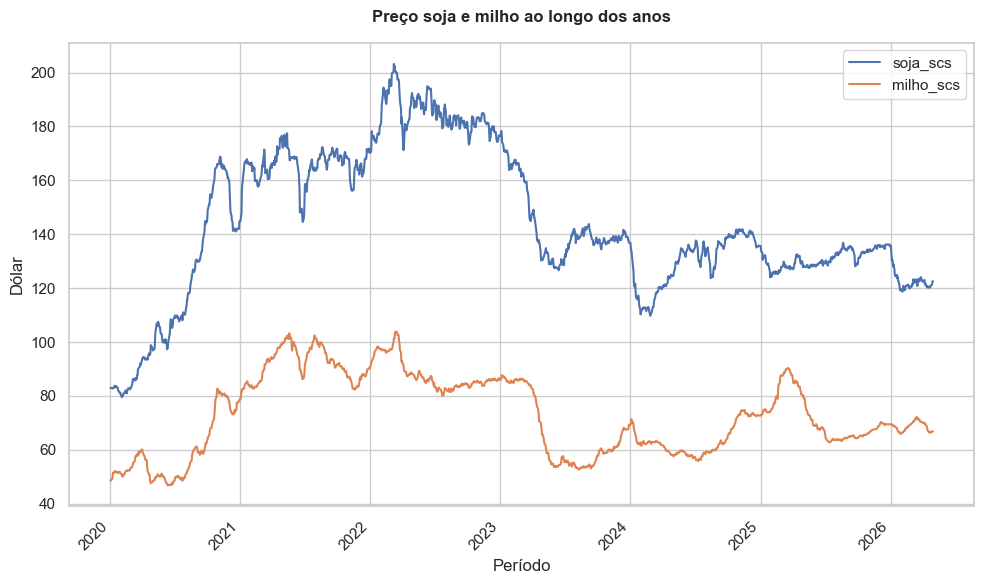

In [169]:
features = ['soja_scs','milho_scs']

plt.figure(figsize=(10,6))
for col in features:
    sns.lineplot(
    data=df_main, 
    x="data", 
    y=col, 
    label=col,
    linewidth=1.5)

plt.title('Preço soja e milho ao longo dos anos', fontweight='bold', pad=15)
plt.xlabel('Período')
plt.ylabel('Dólar')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()